In [50]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset
import numpy as np

In [51]:
import pandas as pd
df=pd.read_csv("../data/preprocessed/market_data/nifty50.csv")
df.head()

,Date,day_return_scaled,RSI,Sortino,MACD,emaslope_15d,tr,atr_15d,bb_width_15d,zscore_15d,ret_15d,max_dd_15d,vol_15d,sharpe_ratio_15,var95_15,cvar95_15,beta_15,alpha_5d,category
0,2023-04-03,-1.715545,52.354288,-0.037909,0.000000,1.181236,9.449885,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
1,2023-04-05,7.734340,52.354288,-0.037909,-0.753837,1.181236,9.449885,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
2,2023-04-06,3.724269,52.354288,-0.037909,-1.015968,0.532322,4.010071,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
3,2023-04-10,-0.615235,52.354288,-0.037909,-0.863591,-0.076656,4.339505,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
4,2023-04-11,0.988432,52.354288,-0.037909,-0.862295,0.133384,1.603668,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0


In [52]:
df=df.sort_values("Date")
df=df.set_index("Date")
df.head()

,day_return_scaled,RSI,Sortino,MACD,emaslope_15d,tr,atr_15d,bb_width_15d,zscore_15d,ret_15d,max_dd_15d,vol_15d,sharpe_ratio_15,var95_15,cvar95_15,beta_15,alpha_5d,category
Date,,,,,,,,,,,,,,,,,,
2023-04-03,-1.715545,52.354288,-0.037909,0.000000,1.181236,9.449885,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
2023-04-05,7.734340,52.354288,-0.037909,-0.753837,1.181236,9.449885,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
2023-04-06,3.724269,52.354288,-0.037909,-1.015968,0.532322,4.010071,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
2023-04-10,-0.615235,52.354288,-0.037909,-0.863591,-0.076656,4.339505,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0
2023-04-11,0.988432,52.354288,-0.037909,-0.862295,0.133384,1.603668,3.395366,253.043667,0.646375,-4.336188,-1.818472,62.469912,0.014889,-6.816541,-8.741555,0.243553,-0.030787,0


In [53]:
class dataset(Dataset):
    def __init__(self, market_dataset_path, stock_dataset_path, sequence_length=14):
        self.mkd = []
        self.skd = []
        self.targets = []
        
        # Load market data
        for path in market_dataset_path:
            df = pd.read_csv(path)
            df = df.sort_values("Date")
            self.mkd.append(df)
        
        # Load stock data
        for path in stock_dataset_path:
            df = pd.read_csv(path)
            df = df.sort_values("Date")
            self.targets.append(df[["Date","target"]])  # Store target values separately
            df=df.drop(columns=["target"])
            self.skd.append(df)

        # Find common dates
        common_dates_mkd = set(self.mkd[0]['Date'])
        for df in self.mkd[1:]:
            common_dates_mkd = common_dates_mkd.intersection(set(df['Date']))
            
        common_dates_skd = set(self.skd[0]['Date'])
        for df in self.skd[1:]:
            common_dates_skd = common_dates_skd.intersection(set(df['Date']))

        self.common_dates = common_dates_mkd.intersection(common_dates_skd)
        self.common_dates = sorted(list(self.common_dates))

        # Filter and set index for each market dataframe
        filtered_mkd = []
        for df in self.mkd:
            filtered_df = df[df['Date'].isin(self.common_dates)].copy()
            filtered_df = filtered_df.sort_values("Date")
            filtered_df = filtered_df.set_index('Date')
            filtered_mkd.append(filtered_df)
        self.mkd = filtered_mkd

        # Filter and set index for each stock dataframe
        filtered_skd = []
        for df in self.skd:
            filtered_df = df[df['Date'].isin(self.common_dates)].copy()
            filtered_df = filtered_df.sort_values("Date")
            filtered_df = filtered_df.set_index('Date')
            filtered_skd.append(filtered_df)
        self.skd = filtered_skd

        filtered_targets = []
        for df in self.targets:
            filtered_df = df[df['Date'].isin(self.common_dates)].copy()
            filtered_df = filtered_df.sort_values("Date")
            filtered_df = filtered_df.set_index('Date')
            filtered_targets.append(filtered_df)
        self.targets = filtered_targets

        # ===== ADD NORMALIZATION =====
        # Calculate mean and std from all data
        all_market = np.concatenate([df.values for df in self.mkd], axis=0)
        all_stock = np.concatenate([df.values for df in self.skd], axis=0)
        
        self.market_mean = torch.tensor(all_market.mean(axis=0), dtype=torch.float32)
        self.market_std = torch.tensor(all_market.std(axis=0) + 1e-8, dtype=torch.float32)
        self.stock_mean = torch.tensor(all_stock.mean(axis=0), dtype=torch.float32)
        self.stock_std = torch.tensor(all_stock.std(axis=0) + 1e-8, dtype=torch.float32)
        
        # Normalize the dataframes
        for i in range(len(self.mkd)):
            self.mkd[i] = (self.mkd[i] - self.market_mean.numpy()) / self.market_std.numpy()
        
        for i in range(len(self.skd)):
            self.skd[i] = (self.skd[i] - self.stock_mean.numpy()) / self.stock_std.numpy()
        
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.common_dates) - self.sequence_length - 1

    def __getitem__(self, idx):
        start_idx = idx
        end_idx = idx + self.sequence_length
        target_idx = end_idx
        
        # Collect market data sequences
        market_data = []
        market_target_data = []
        for df in self.mkd:
            seq_data = df.iloc[start_idx:end_idx].values
            target_data = df.iloc[target_idx].values
            market_data.append(seq_data)
            market_target_data.append(target_data)

        target=[]
        for df in self.targets:
            target_data = df.iloc[target_idx].values
            target.append(target_data)
        
        # Collect stock data sequences
        stock_data = []
        stock_target_data = []
        for df in self.skd:
            seq_data = df.iloc[start_idx:end_idx].values
            target_data = df.iloc[target_idx].values
            stock_data.append(seq_data)
            stock_target_data.append(target_data)
        
        # Convert to tensors
        market_data = torch.tensor(np.array(market_data), dtype=torch.float32)
        stock_data = torch.tensor(np.array(stock_data), dtype=torch.float32)
        market_target_data = torch.tensor(np.array(market_target_data), dtype=torch.float32)
        stock_target_data = torch.tensor(np.array(stock_target_data), dtype=torch.float32)
        target = torch.tensor(np.array(target), dtype=torch.float32)
        
        # ===== CRITICAL FIXES =====
        # 1. Replace any NaN/Inf
        market_data = torch.nan_to_num(market_data, nan=0.0, posinf=10.0, neginf=-10.0)
        stock_data = torch.nan_to_num(stock_data, nan=0.0, posinf=10.0, neginf=-10.0)
        market_target_data = torch.nan_to_num(market_target_data, nan=0.0, posinf=10.0, neginf=-10.0)
        stock_target_data = torch.nan_to_num(stock_target_data, nan=0.0, posinf=10.0, neginf=-10.0)
        
        # 2. Clip extreme values to prevent overflow
        market_data = torch.clamp(market_data, min=-5.0, max=5.0)
        stock_data = torch.clamp(stock_data, min=-5.0, max=5.0)
        market_target_data = torch.clamp(market_target_data, min=-5.0, max=5.0)
        stock_target_data = torch.clamp(stock_target_data, min=-5.0, max=5.0)
        
        return market_data, stock_data, market_target_data, stock_target_data ,target

In [54]:
PREPROCESSED_DIR_NSE = "../data/preprocessed/market_data"
PREPROCESSED_DIR_STOCK = "../data/preprocessed/stock_data"
nse_tickers={
    # Broad Market Indices (Most commonly tracked)
    "NIFTY 50": "^NSEI",
    "BSE Sensex": "^BSESN",
    "NIFTY BANK": "^NSEBANK",
    "INDIA VIX": "^INDIAVIX",
    "NIFTY NEXT 50": "^NSMIDCP",
    # Nifty Broad Market
    "NIFTY 100": "^CNX100",
    "NIFTY 200": "^CNX200",
    "NIFTY 500": "^CRSLDX",
    # Exchange 
    "Gold Futures": "GC=F",
    "USDINR": "USDINR=X",
    "Crude Oil Futures": "CL=F",
}

stocks_cat={
    "Reliance Industries": 0,
    "Tata Consultancy Services": 1,
    "Infosys": 2,
    "HDFC Bank": 3,
    "ICICI Bank": 4,
    "State Bank of India": 5,
    "Kotak Mahindra Bank": 6,
    "Axis Bank": 7,
    "Hindustan Unilever": 8,
    "ITC": 9,
    "Larsen & Toubro": 10,
    "Asian Paints": 11,
    "Bajaj Finance": 12,
    "Bajaj Finserv": 13,
    "Maruti Suzuki": 14,
    "Mahindra & Mahindra": 15,
    "Sun Pharma": 16,
    "Dr Reddy's Laboratories": 17,
    "Cipla": 18,
    "Wipro": 19,
    "HCL Technologies": 20,
    "Tech Mahindra": 21,
    "UltraTech Cement": 22,
    "Tata Steel": 23,
    "JSW Steel": 24,
    "Power Grid Corporation": 25,
    "NTPC": 26,
    "Adani Enterprises": 27,
    "Adani Ports": 28
}


nse_cat={
    # Broad Market Indices (Most commonly tracked)
    "NIFTY 50": 0,
    "BSE Sensex": 1,
    "NIFTY BANK": 2,
    "INDIA VIX": 3,
    "NIFTY NEXT 50": 4,
    # Nifty Broad Market
    "NIFTY 100": 5,
    "NIFTY 200": 6,
    "NIFTY 500": 7,
    # Exchange 
    "Gold Futures": 8,
    "USDINR": 9,
    "Crude Oil Futures": 10,
}

In [55]:
market_dataset_path = []
for name in nse_cat.keys():
    print(f"{name},")
    name = name.lower()
    name = name.replace(" ", "")
    name = name.replace(":", "_")
    name = name.replace("/", "_")
    
    market_dataset_path.append(f"{PREPROCESSED_DIR_NSE}/{name}.csv")

NIFTY 50,
BSE Sensex,
NIFTY BANK,
INDIA VIX,
NIFTY NEXT 50,
NIFTY 100,
NIFTY 200,
NIFTY 500,
Gold Futures,
USDINR,
Crude Oil Futures,


In [56]:
stock_dataset_path = []
for name in stocks_cat.keys():
    print(f"{name},")
    name = name.lower()
    name = name.replace(" ", "")
    name = name.replace(":", "_")
    name = name.replace("/", "_")
    stock_dataset_path.append(f"{PREPROCESSED_DIR_STOCK}/{name}.csv")

Reliance Industries,
Tata Consultancy Services,
Infosys,
HDFC Bank,
ICICI Bank,
State Bank of India,
Kotak Mahindra Bank,
Axis Bank,
Hindustan Unilever,
ITC,
Larsen & Toubro,
Asian Paints,
Bajaj Finance,
Bajaj Finserv,
Maruti Suzuki,
Mahindra & Mahindra,
Sun Pharma,
Dr Reddy's Laboratories,
Cipla,
Wipro,
HCL Technologies,
Tech Mahindra,
UltraTech Cement,
Tata Steel,
JSW Steel,
Power Grid Corporation,
NTPC,
Adani Enterprises,
Adani Ports,


In [57]:
full_dataset = dataset(market_dataset_path, stock_dataset_path)

In [58]:
for mkd,stkd, mkd_tgt, stkd_tgt,target in iter(full_dataset):
    print(mkd.shape)
    print(stkd.shape)
    print(mkd_tgt.shape)
    print(stkd_tgt.shape)
    print(target.shape)
    print(target)
    break

torch.Size([11, 14, 18])
torch.Size([29, 14, 18])
torch.Size([11, 18])
torch.Size([29, 18])
torch.Size([29, 1])
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.]])


In [59]:
# Chronological split (most common)
from torch.utils.data import Subset
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_size = int(train_ratio * len(full_dataset))
val_size = int(val_ratio * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

# Maintain temporal order
train_dataset = Subset(full_dataset, range(train_size))
val_dataset = Subset(full_dataset, range(train_size, train_size + val_size))
test_dataset = Subset(full_dataset, range(train_size + val_size, len(full_dataset)))

print(f"Train: {len(train_dataset)} samples")
print(f"Validation: {len(val_dataset)} samples") 
print(f"Test: {len(test_dataset)} samples")

Train: 489 samples
Validation: 104 samples
Test: 106 samples


In [60]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [61]:
market_data, stock_data, market_target, stock_target, target = next(iter(train_loader))

print(market_data.shape)
print(stock_data.shape)
print(market_target.shape)
print(stock_target.shape)
print(target.shape)

torch.Size([32, 11, 14, 18])
torch.Size([32, 29, 14, 18])
torch.Size([32, 11, 18])
torch.Size([32, 29, 18])
torch.Size([32, 29, 1])


In [62]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=18, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1, num_market_indices=11):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
        self.num_market_indices = num_market_indices
        self.input_dim = input_dim
        
        self.input_projection = nn.Linear(input_dim, d_model)
        
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=100)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        self.output_projection = nn.Linear(d_model, input_dim)
        
        self.attention_pool = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        
    def forward(self, x):
        batch_size, num_indices, seq_len, input_dim = x.shape
        x = x.view(batch_size * num_indices, seq_len, input_dim)
        
        x = self.input_projection(x)
        
        x = x * math.sqrt(self.d_model)
        
        x = self.positional_encoding(x)
        
        x = self.transformer_encoder(x)
        
        x = x[:, -1, :]
        
        x = self.layer_norm(x)
        x = self.dropout(x)
        
        output = self.output_projection(x)
        
        output = output.view(batch_size, num_indices, input_dim)
        
        return output


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class EnhancedTimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=18, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1, num_market_indices=11):
        super(EnhancedTimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
        self.num_market_indices = num_market_indices
        
        # Separate embedding for each market index (optional)
        self.index_embeddings = nn.Parameter(torch.randn(num_market_indices, d_model))
        
        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # Cross-attention between market indices
        self.cross_attention = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        
        # Output layers
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
        # Prediction head
        self.output_projection = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, input_dim)
        )
        
    def forward(self, x):
        """
        Args:
            x: (batch_size, num_market_indices, sequence_length, input_dim)
        Returns:
            output: (batch_size, num_market_indices, input_dim)
        """
        batch_size, num_indices, seq_len, input_dim = x.shape
        
        # Reshape for transformer
        x = x.view(batch_size * num_indices, seq_len, input_dim)
        
        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Apply transformer
        x = self.transformer(x)  # (batch*num_indices, seq_len, d_model)
        
        # Take last timestep
        x = x[:, -1, :]  # (batch*num_indices, d_model)
        
        # Reshape back
        x = x.view(batch_size, num_indices, self.d_model)
        
        # Add index embeddings
        x = x + self.index_embeddings.unsqueeze(0)
        
        # Cross-attention between market indices
        x = x.transpose(0, 1)  # (num_indices, batch, d_model)
        x, _ = self.cross_attention(x, x, x)
        x = x.transpose(0, 1)  # (batch, num_indices, d_model)
        
        # Apply layer norm and residual
        x = self.layer_norm1(x)
        x = self.dropout(x)
        
        # Output projection
        output = self.output_projection(x)
        
        return output


# Training setup
def create_model_and_optimizer():
    model = TimeSeriesTransformer(
        input_dim=18,
        d_model=128,        # Hidden dimension
        nhead=8,            # Number of attention heads
        num_layers=3,       # Number of transformer layers
        dim_feedforward=256,# Feedforward dimension
        dropout=0.1,
        num_market_indices=11
    )
    
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    
    # Loss function (for regression)
    criterion = nn.MSELoss()
    
    return model, optimizer, criterion


# Usage example
if __name__ == "__main__":
    # Test with your data shape
    batch_size = 32
    num_indices = 11
    seq_len = 14
    input_dim = 18
    
    # Sample input
    sample_input = torch.randn(batch_size, num_indices, seq_len, input_dim)
    
    # Create model
    model = TimeSeriesTransformer(
        input_dim=input_dim,
        d_model=128,
        nhead=8,
        num_layers=3,
        num_market_indices=num_indices
    )
    
    # Forward pass
    output = model(sample_input)
    print(f"Input shape: {sample_input.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Expected output shape: torch.Size([{batch_size}, {num_indices}, {input_dim}])")
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

Input shape: torch.Size([32, 11, 14, 18])
Output shape: torch.Size([32, 11, 18])
Expected output shape: torch.Size([32, 11, 18])

Total parameters: 468,498
Trainable parameters: 468,498


In [63]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== DEFINE MODELS ====================

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,  # Reduced dimensions
                 dim_feedforward=128, dropout=0.1, num_series=11):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
        
        # Input normalization
        self.input_norm = nn.LayerNorm(input_dim)
        
        # Input projection with smaller initialization
        self.input_projection = nn.Linear(input_dim, d_model)
        nn.init.xavier_uniform_(self.input_projection.weight, gain=0.1)  # Smaller gain
        nn.init.zeros_(self.input_projection.bias)
        
        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=100)
        
        # Transformer Encoder with stability improvements
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            dropout=dropout, 
            batch_first=True,
            activation='gelu'  # More stable than ReLU
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output layers
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.output_projection = nn.Linear(d_model, input_dim)
        nn.init.xavier_uniform_(self.output_projection.weight, gain=0.1)
        nn.init.zeros_(self.output_projection.bias)
        
    def forward(self, x):
        batch_size, num_series, seq_len, input_dim = x.shape
        
        # Normalize input
        x = self.input_norm(x)
        
        # Reshape: (batch_size * num_series, seq_len, input_dim)
        x = x.view(batch_size * num_series, seq_len, input_dim)
        
        # Project to d_model
        x = self.input_projection(x)
        
        # Scale (using smaller scaling)
        x = x * (0.1)  # Instead of sqrt(d_model)
        
        # Add positional encoding
        x = self.positional_encoding(x)
        
        # Apply transformer
        x = self.transformer_encoder(x)
        
        # Take last timestep
        x = x[:, -1, :]
        
        # Output projection
        x = self.layer_norm(x)
        x = self.dropout(x)
        output = self.output_projection(x)
        
        # Reshape back
        output = output.view(batch_size, num_series, input_dim)
        
        return output
    
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Use smaller values for positional encoding
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe * 0.1  # Scale down positional encoding
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


Using device: cuda


Using device: cuda
Market Model Parameters: 69494
Stock Model Parameters: 69494

Starting training...


Epoch 1/500 [Train]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/500 [Val]: 100%|██████████| 4/4 [00:00<00:00, 13.46it/s, mkt_loss=0.524, stk_loss=0.601]


  ✓ Saved best market model (val_loss: 0.464395)
  ✓ Saved best stock model (val_loss: 0.578357)

Epoch 1/500
  Train - Market: 0.576392, Stock: 0.824769
  Val   - Market: 0.464395, Stock: 0.578357
  LR    - Market: 0.000100, Stock: 0.000100
------------------------------------------------------------


Epoch 2/500 [Val]: 100%|██████████| 4/4 [00:00<00:00, 14.73it/s, mkt_loss=0.519, stk_loss=0.597]


...


Epoch 498/500
  Train - Market: 0.217604, Stock: 0.393717
  Val   - Market: 0.177812, Stock: 0.275696
  LR    - Market: 0.000000, Stock: 0.000000
------------------------------------------------------------


Epoch 499/500 [Val]: 100%|██████████| 4/4 [00:00<00:00,  7.54it/s, mkt_loss=0.213, stk_loss=0.295]



Epoch 499/500
  Train - Market: 0.217322, Stock: 0.394168
  Val   - Market: 0.177812, Stock: 0.275696
  LR    - Market: 0.000000, Stock: 0.000000
------------------------------------------------------------


Epoch 500/500 [Val]: 100%|██████████| 4/4 [00:00<00:00, 13.25it/s, mkt_loss=0.213, stk_loss=0.295]



Epoch 500/500
  Train - Market: 0.217762, Stock: 0.393517
  Val   - Market: 0.177812, Stock: 0.275696
  LR    - Market: 0.000000, Stock: 0.000000
------------------------------------------------------------

Training completed!


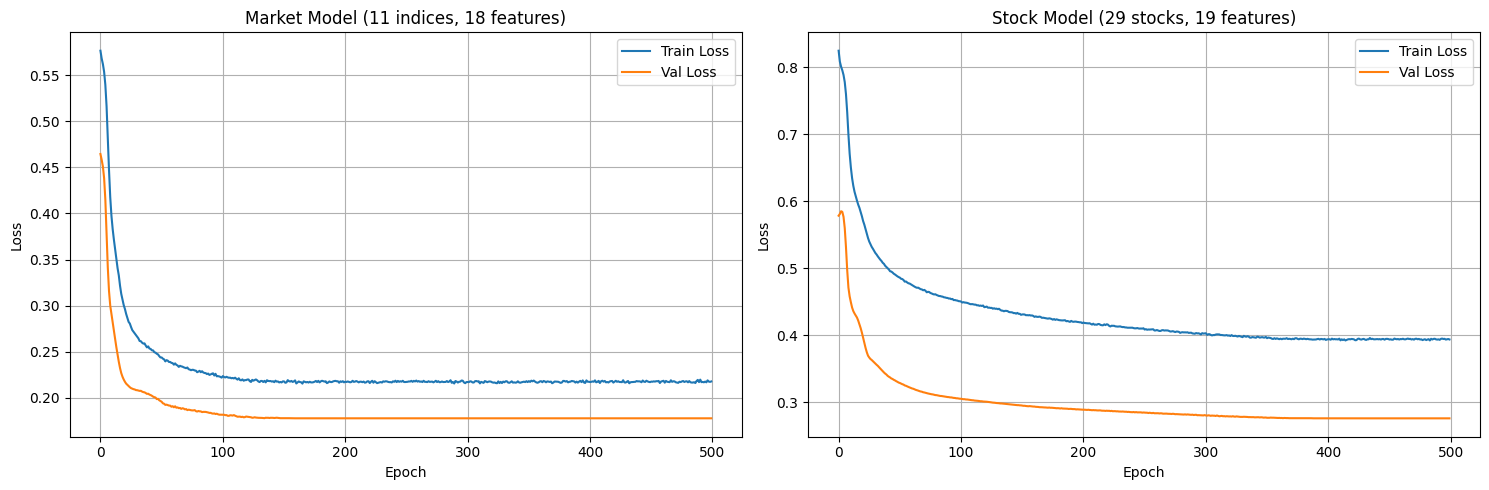

ValueError: too many values to unpack (expected 4)

In [140]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== DEFINE MODELS ====================

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2,  # Reduced dimensions
                 dim_feedforward=128, dropout=0.1, num_series=11):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
        
        # Input normalization
        self.input_norm = nn.LayerNorm(input_dim)
        
        # Input projection with smaller initialization
        self.input_projection = nn.Linear(input_dim, d_model)
        nn.init.xavier_uniform_(self.input_projection.weight, gain=0.1)  # Smaller gain
        nn.init.zeros_(self.input_projection.bias)
        
        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=100)
        
        # Transformer Encoder with stability improvements
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            dropout=dropout, 
            batch_first=True,
            activation='gelu'  # More stable than ReLU
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output layers
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.output_projection = nn.Linear(d_model, input_dim)
        nn.init.xavier_uniform_(self.output_projection.weight, gain=0.1)
        nn.init.zeros_(self.output_projection.bias)
        
    def forward(self, x):
        batch_size, num_series, seq_len, input_dim = x.shape
        
        # Normalize input
        x = self.input_norm(x)
        
        # Reshape: (batch_size * num_series, seq_len, input_dim)
        x = x.view(batch_size * num_series, seq_len, input_dim)
        
        # Project to d_model
        x = self.input_projection(x)
        
        # Scale (using smaller scaling)
        x = x * (0.1)  # Instead of sqrt(d_model)
        
        # Add positional encoding
        x = self.positional_encoding(x)
        
        # Apply transformer
        x = self.transformer_encoder(x)
        
        # Take last timestep
        x = x[:, -1, :]
        
        # Output projection
        x = self.layer_norm(x)
        x = self.dropout(x)
        output = self.output_projection(x)
        
        # Reshape back
        output = output.view(batch_size, num_series, input_dim)
        
        return output
    
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Use smaller values for positional encoding
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe * 0.1  # Scale down positional encoding
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ==================== CREATE MODELS ====================

# Market model (11 indices, 18 features)
# Create models with smaller dimensions
market_model = TimeSeriesTransformer(
    input_dim=18,
    d_model=64,      # Reduced from 128
    nhead=4,         # Reduced from 8
    num_layers=2,    # Reduced from 3
    dim_feedforward=128,  # Reduced from 256
    dropout=0.2,     # Increased dropout
    num_series=11
).to(device)

stock_model = TimeSeriesTransformer(
    input_dim=18,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.2,
    num_series=29
).to(device)

print("Market Model Parameters:", sum(p.numel() for p in market_model.parameters()))
print("Stock Model Parameters:", sum(p.numel() for p in stock_model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer_market = torch.optim.Adam(market_model.parameters(), lr=0.0001, weight_decay=1e-5)
optimizer_stock = torch.optim.Adam(stock_model.parameters(), lr=0.0001, weight_decay=1e-5)

criterion = nn.MSELoss()

scheduler_market = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_market, mode='min', factor=0.5, patience=5)
scheduler_stock = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_stock, mode='min', factor=0.5, patience=5)

# ==================== TRAINING LOOP ====================

num_epochs = 500
best_market_loss = float('inf')
best_stock_loss = float('inf')

train_market_losses = []
train_stock_losses = []
val_market_losses = []
val_stock_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    market_model.train()
    stock_model.train()
    
    train_market_loss = 0
    train_stock_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for market_data, stock_data, market_target, stock_target, target in train_bar:
        # Move to device
        market_data = market_data.to(device)  # (batch, 11, 14, 18)
        stock_data = stock_data.to(device)    # (batch, 29, 14, 19)
        market_target = market_target.to(device)  # (batch, 11, 18)
        stock_target = stock_target.to(device)    # (batch, 29, 19)
        
        # Train Market Model
        optimizer_market.zero_grad()
        market_output = market_model(market_data)
        market_loss = criterion(market_output, market_target)
        market_loss.backward()
        torch.nn.utils.clip_grad_norm_(market_model.parameters(), max_norm=1.0)
        optimizer_market.step()
        
        # Train Stock Model
        optimizer_stock.zero_grad()
        stock_output = stock_model(stock_data)
        stock_loss = criterion(stock_output, stock_target)
        stock_loss.backward()
        torch.nn.utils.clip_grad_norm_(stock_model.parameters(), max_norm=1.0)
        optimizer_stock.step()
        
        train_market_loss += market_loss.item()
        train_stock_loss += stock_loss.item()
        
        train_bar.set_postfix({
            'mkt_loss': market_loss.item(),
            'stk_loss': stock_loss.item()
        })
    
    avg_train_market = train_market_loss / len(train_loader)
    avg_train_stock = train_stock_loss / len(train_loader)
    train_market_losses.append(avg_train_market)
    train_stock_losses.append(avg_train_stock)
    
    # Validation phase
    market_model.eval()
    stock_model.eval()
    
    val_market_loss = 0
    val_stock_loss = 0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for market_data, stock_data, market_target, stock_target, target in val_bar:
            market_data = market_data.to(device)
            stock_data = stock_data.to(device)
            market_target = market_target.to(device)
            stock_target = stock_target.to(device)
            target = target.to(device)

            market_output = market_model(market_data)
            stock_output = stock_model(stock_data)
            
            market_loss = criterion(market_output, market_target)
            stock_loss = criterion(stock_output, stock_target)
            
            val_market_loss += market_loss.item()
            val_stock_loss += stock_loss.item()
            
            val_bar.set_postfix({
                'mkt_loss': market_loss.item(),
                'stk_loss': stock_loss.item()
            })
    
    avg_val_market = val_market_loss / len(val_loader)
    avg_val_stock = val_stock_loss / len(val_loader)
    val_market_losses.append(avg_val_market)
    val_stock_losses.append(avg_val_stock)
    
    # Update schedulers
    scheduler_market.step(avg_val_market)
    scheduler_stock.step(avg_val_stock)
    
    # Save best models
    if avg_val_market < best_market_loss:
        best_market_loss = avg_val_market
        torch.save(market_model.state_dict(), 'best_market_model.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val_market:.6f})")
    
    if avg_val_stock < best_stock_loss:
        best_stock_loss = avg_val_stock
        torch.save(stock_model.state_dict(), 'best_stock_model.pth')
        print(f"  ✓ Saved best stock model (val_loss: {avg_val_stock:.6f})")
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train - Market: {avg_train_market:.6f}, Stock: {avg_train_stock:.6f}")
    print(f"  Val   - Market: {avg_val_market:.6f}, Stock: {avg_val_stock:.6f}")
    print(f"  LR    - Market: {optimizer_market.param_groups[0]['lr']:.6f}, Stock: {optimizer_stock.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_market_losses, label='Train Loss')
axes[0].plot(val_market_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Market Model (11 indices, 18 features)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_stock_losses, label='Train Loss')
axes[1].plot(val_stock_losses, label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Stock Model (29 stocks, 19 features)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# ==================== TEST EVALUATION ====================

# Load best models
market_model.load_state_dict(torch.load('best_market_model.pth'))
stock_model.load_state_dict(torch.load('best_stock_model.pth'))

market_model.eval()
stock_model.eval()

market_predictions = []
market_actuals = []
stock_predictions = []
stock_actuals = []

with torch.no_grad():
    for market_data, stock_data, market_target, stock_target in test_loader:
        market_data = market_data.to(device)
        stock_data = stock_data.to(device)
        
        market_output = market_model(market_data)
        stock_output = stock_model(stock_data)
        
        market_predictions.append(market_output.cpu().numpy())
        market_actuals.append(market_target.numpy())
        stock_predictions.append(stock_output.cpu().numpy())
        stock_actuals.append(stock_target.numpy())

market_predictions = np.concatenate(market_predictions, axis=0)
market_actuals = np.concatenate(market_actuals, axis=0)
stock_predictions = np.concatenate(stock_predictions, axis=0)
stock_actuals = np.concatenate(stock_actuals, axis=0)

# Calculate metrics
market_mse = np.mean((market_predictions - market_actuals) ** 2)
market_mae = np.mean(np.abs(market_predictions - market_actuals))
stock_mse = np.mean((stock_predictions - stock_actuals) ** 2)
stock_mae = np.mean(np.abs(stock_predictions - stock_actuals))

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"\nMarket Model (11 indices, 18 features):")
print(f"  MSE: {market_mse:.6f}")
print(f"  MAE: {market_mae:.6f}")
print(f"\nStock Model (29 stocks, 19 features):")
print(f"  MSE: {stock_mse:.6f}")
print(f"  MAE: {stock_mae:.6f}")

# Save predictions
np.save('market_predictions.npy', market_predictions)
np.save('market_actuals.npy', market_actuals)
np.save('stock_predictions.npy', stock_predictions)
np.save('stock_actuals.npy', stock_actuals)

print("\nPredictions saved!")

In [72]:
DIM=18

class MarketAggregator(nn.Module):
    """
    Advanced market encoder:
    (B, N_MARKET, DIM) → (B, DIM)

    Features:
    - Multi-head self-attention (cross-market dependencies)
    - Learnable global query (CLS-style pooling)
    - Gated feature fusion (FiLM-like)
    - Residual + LayerNorm
    """

    def __init__(
        self,
        dim: int = 18,
        num_heads: int = 6,
        hidden_dim: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        # --- Self-attention block ---
        self.self_attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(dim)

        # --- Feed-forward (Transformer FFN) ---
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim)
        )

        self.norm2 = nn.LayerNorm(dim)

        # --- Learnable global query (CLS token equivalent) ---
        self.global_query = nn.Parameter(torch.randn(1, 1, dim))

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        # --- Gating mechanism (feature-wise importance) ---
        self.gate = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )

        # --- Final projection ---
        self.out_proj = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, N_MARKET, DIM)
        """

        B = x.size(0)

        # =========================
        # 1. Cross-market interaction
        # =========================
        attn_out, _ = self.self_attn(x, x, x)  # (B, N, D)
        x = self.norm1(x + attn_out)

        # =========================
        # 2. Transformer FFN
        # =========================
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        # =========================
        # 3. Global query pooling (CLS-style)
        # =========================
        query = self.global_query.expand(B, -1, -1)  # (B, 1, D)
        pooled, _ = self.cross_attn(query, x, x)     # (B, 1, D)
        pooled = pooled.squeeze(1)                  # (B, D)

        # =========================
        # 4. Feature gating (adaptive importance)
        # =========================
        gate = self.gate(pooled)                    # (B, D)
        pooled = pooled * gate

        # =========================
        # 5. Final projection
        # =========================
        z = self.out_proj(pooled)

        return z


class FusionV2(nn.Module):
    """
    Advanced fusion:
    Inputs:
        s: (B, D) → stock embedding
        m: (B, D) → market embedding

    Output:
        (B, D) → market-aware stock representation
    """

    def __init__(
        self,
        dim: int = 18,
        hidden_dim: int = 64,
        num_heads: int = 2,
        dropout: float = 0.1
    ):
        super().__init__()

        # =========================
        # 1. FiLM conditioning (market → stock modulation)
        # =========================
        self.film = nn.Sequential(
            nn.Linear(dim, dim * 2)  # gamma, beta
        )

        # =========================
        # 2. Bilinear interaction (2nd order)
        # =========================
        self.bilinear = nn.Bilinear(dim, dim, dim)

        # =========================
        # 3. Cross-attention (stock queries market)
        # =========================
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        # =========================
        # 4. Gating mechanism
        # =========================
        self.gate = nn.Sequential(
            nn.Linear(dim * 3, dim),
            nn.Sigmoid()
        )

        # =========================
        # 5. Deep fusion MLP
        # =========================
        self.mlp = nn.Sequential(
            nn.Linear(dim * 4, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim)
        )

        self.norm = nn.LayerNorm(dim)

    def forward(self, s: torch.Tensor, m: torch.Tensor) -> torch.Tensor:
        """
        s, m: (B, D)
        """

        # =========================
        # 1. FiLM modulation
        # =========================
        gamma, beta = self.film(m).chunk(2, dim=-1)
        s_film = gamma * s + beta   # (B, D)

        # =========================
        # 2. Bilinear interaction
        # =========================
        bilinear_feat = self.bilinear(s, m)  # (B, D)

        # =========================
        # 3. Cross-attention
        # =========================
        s_q = s.unsqueeze(1)  # (B, 1, D)
        m_kv = m.unsqueeze(1)

        attn_out, _ = self.cross_attn(s_q, m_kv, m_kv)
        attn_out = attn_out.squeeze(1)  # (B, D)

        # =========================
        # 4. Combine interactions
        # =========================
        interaction = s * m

        fusion_stack = torch.cat(
            [s_film, bilinear_feat, attn_out, interaction],
            dim=-1
        )  # (B, 4D)

        fused = self.mlp(fusion_stack)

        # =========================
        # 5. Adaptive gating
        # =========================
        gate_input = torch.cat([s, m, fused], dim=-1)
        gate = self.gate(gate_input)

        out = gate * fused + (1 - gate) * s

        # =========================
        # 6. Residual + norm
        # =========================
        out = self.norm(out + s)

        return out# (B, DIM)


class SurrogateHead_(nn.Module):
    """Thin linear head used *only* during NN pre-training to produce a scalar prediction."""

    def __init__(self, dim: int = DIM):
        super().__init__()
        self.fc = nn.Linear(dim, 1)
        self.sigmoid = nn.Sigmoid()  # Ensure output is between 0 and 1

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.sigmoid(self.fc(z))  # (B, 1)
    
class SurrogateHead(nn.Module):
    """
    Stronger surrogate head for representation learning.
    Outputs raw logits (no sigmoid).
    """

    def __init__(
        self,
        dim: int = 18,
        hidden_dim: int = 64,
        dropout: float = 0.1
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),

            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)  # (B, 1) → RAW LOGITS

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch import optim
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold

In [73]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report

N_STOCKS=29
class MarketPipeline:
    def __init__(
        self,
        dim: int = DIM,
        market_indices: list[int] | None = None,
        lr: float = 1e-3,
        nn_epochs: int = 100,
        device: str | None = None,
        xgb_params: dict | None = None,
        load_pretrained: bool = True,  # Set to False if you don't have files
    ):
        self.dim = dim
        self.device = torch.device(device if device else ("cuda" if torch.cuda.is_available() else "cpu"))
        self.lr = lr
        self.nn_epochs = nn_epochs

        # Build NN modules
        self.aggregator = MarketAggregator(dim).to(self.device)
        self.fusion = FusionV2(dim).to(self.device)
        self.head = SurrogateHead(dim).to(self.device)

        # XGBoost params
        self.xgb_params = xgb_params or {
            "objective": "reg:squarederror",
            "max_depth": 6,
            "learning_rate": 0.05,
            "n_estimators": 300,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "tree_method": "hist",
            "seed": 42,
        }
        self.xgb_model = None

        # Create transformer models
        self.market_model = TimeSeriesTransformer(
            input_dim=18,
            d_model=64,
            nhead=4,
            num_layers=2,
            dim_feedforward=128,
            dropout=0.2,
            num_series=11
        ).to(self.device)

        self.stock_model = TimeSeriesTransformer(
            input_dim=18,
            d_model=64,
            nhead=4,
            num_layers=2,
            dim_feedforward=128,
            dropout=0.2,
            num_series=29
        ).to(self.device)

        # FIX: Load pretrained models if requested
        if load_pretrained:
            try:
                # Load state dict and move to device in one step
                market_state = torch.load('best_market_model.pth', map_location=self.device)
                self.market_model.load_state_dict(market_state)
                
                stock_state = torch.load('best_stock_model.pth', map_location=self.device)
                self.stock_model.load_state_dict(stock_state)
                
                print(f"✅ Loaded pretrained models to {self.device}")
                
                # Set to eval mode but keep for training? 
                # If you want to FINE-TUNE, use train mode
                # If you want to FREEZE, use eval and disable gradients
                self.market_model.train()  # Enable fine-tuning
                self.stock_model.train()   # Enable fine-tuning
                
            except FileNotFoundError as e:
                print(f"⚠️ Pretrained files not found: {e}")
                print("📝 Training transformers from scratch")
                load_pretrained = False
        else:
            print("📝 Training transformers from scratch")
    # ── helpers ──────────────────────────────

    def _nn_params(self):
        return (
            list(self.aggregator.parameters())
            + list(self.fusion.parameters())
            + list(self.head.parameters())
        )

    @torch.no_grad()  # Add this decorator to ensure no gradients are computed
    def _extract_features(self, skd_matrix: torch.Tensor, mkd_matrix: torch.Tensor) -> np.ndarray:
        """
        Forward pass through MarketAggregator + FusionV2 for ALL 29 stocks.

        Args:
            skd_matrix : (B, 29, 18)
            mkd_matrix : (B, 11, 18)

        Returns:
            features : (B * 29, 18) numpy array  ← XGBoost input
        """
        # No need to set eval mode here as it should be set by caller
        B = skd_matrix.shape[0]

        # Ensure tensors are on correct device
        skd_matrix = skd_matrix.to(self.device)
        mkd_matrix = mkd_matrix.to(self.device)

        market_vec = self.aggregator(mkd_matrix)  # (B, 18)

        fused_list = []
        for stock_idx in range(N_STOCKS):
            s_vec = skd_matrix[:, stock_idx, :]               # (B, 18)
            fused = self.fusion(s_vec, market_vec)            # (B, 18)
            fused_list.append(fused)

        # Stack → (B, 29, 18), then flatten → (B*29, 18)
        features = torch.stack(fused_list, dim=1)    # (B, 29, 18)
        return features.cpu().numpy().reshape(B * N_STOCKS, self.dim)  # Move to CPU for numpy

    # ── Phase 1: NN pre-training ──────────────

    def pretrain_nn(self, loader: DataLoader) -> list[float]:
        """
        Pre-train MarketAggregator + FusionV2 with a surrogate MSE loss.
        Uses only one target per stock (the first target column if multi-target).

        Returns list of per-epoch average losses.
        """
        print("── Phase 1: NN surrogate pre-training ──")
        optimizer = optim.Adam(self._nn_params(), lr=self.lr)
        criterion = nn.BCEWithLogitsLoss()
        epoch_losses = []

        self.aggregator.train()
        self.fusion.train()
        self.head.train()
        self.market_model.train()  # Add these
        self.stock_model.train()   # Add these

        for epoch in range(1, self.nn_epochs + 1):
            batch_losses = []

            for market_data, stock_data, market_target, stock_target, target in loader:
                # Move all data to device
                market_data = market_data.to(self.device)  # (B, 11, 14, 18)
                stock_data = stock_data.to(self.device)    # (B, 29, 14, 18)
                target = target.to(self.device)            # (B, 29, 1) - FIX: Move target to device

                B = stock_data.shape[0]

                market_output = self.market_model(market_data)  # (B, 11, 18)
                stock_output = self.stock_model(stock_data)     # (B, 29, 18)

                market_vec = self.aggregator(market_output)     # (B, 18)

                preds_list, targets_list = [], []

                for stock_idx in range(N_STOCKS):
                    s_vec = stock_output[:, stock_idx, :]               # (B, 18)
                    fused = self.fusion(s_vec, market_vec)              # (B, 18)
                    pred = self.head(fused)                             # (B, 1)
                    preds_list.append(pred)
                    targets_list.append(target[:, stock_idx, :])        # (B, 1) - Now on device

                preds = torch.cat(preds_list, dim=0)    # (B*29, 1)
                targets = torch.cat(targets_list, dim=0) # (B*29, 1)

                loss = criterion(preds, targets)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())

            avg = float(np.mean(batch_losses))
            epoch_losses.append(avg)
            print(f"  Epoch {epoch:3d}/{self.nn_epochs}  loss={avg:.6f}")

        return epoch_losses
    # ── Phase 2: XGBoost training ─────────────

    def train_xgboost(self, loader: DataLoader) -> None:
        """
        Extract frozen NN features for the full dataset, then fit XGBoost classifier.
        """
        print("── Phase 2: Collecting features for XGBoost ──")
        all_features, all_targets = [], []

        self.market_model.eval()
        self.stock_model.eval()
        self.aggregator.eval()
        self.fusion.eval()

        for market_data, stock_data, market_target, stock_target, target in loader:
            market_data = market_data.to(self.device)
            stock_data = stock_data.to(self.device)
            target = target.to(self.device)

            with torch.no_grad():
                market_output = self.market_model(market_data)
                stock_output = self.stock_model(stock_data)
                feats = self._extract_features(stock_output, market_output)  # (B*29, 18)
                tgts = target.cpu().numpy().reshape(-1)  # Flatten to (B*29,)

            all_features.append(feats)
            all_targets.append(tgts)

        X_xgb = np.vstack(all_features)
        y_xgb = np.concatenate(all_targets)

        print(f"  XGBoost input: X={X_xgb.shape}, y={y_xgb.shape}")
        print(f"  Class distribution: 0={np.sum(y_xgb==0)}, 1={np.sum(y_xgb==1)}")
        
        print("── Fitting XGBoost Classifier ──")
        
        # FIX: Use XGBClassifier for binary classification
        self.xgb_params.update({
            "objective": "binary:logistic",  # Binary classification
            "eval_metric": "logloss",        # Appropriate metric
        })
        
        self.xgb_model = xgb.XGBClassifier(**self.xgb_params)
        self.xgb_model.fit(
            X_xgb, y_xgb,
            verbose=50,
        )
        print("  XGBoost training complete.")

    
    # ── Full pipeline ─────────────────────────

    def fit(self, train_loader: DataLoader, val_loader: DataLoader | None = None, 
            use_optuna: bool = True, n_trials: int = 50):
        """
        Full pipeline: pre-train NN → fit XGBoost with Optuna → optional validation.
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader (optional)
            use_optuna: Whether to use Optuna for hyperparameter optimization
            n_trials: Number of Optuna trials (if use_optuna=True)
        """
        self.pretrain_nn(train_loader)
        
        if use_optuna:
            self.train_xgboost_with_optuna(train_loader, n_trials=n_trials)
        else:
            self.train_xgboost(train_loader)  # Your original method

        if val_loader is not None:
            self.evaluate(val_loader, split="val")

    # ── Inference ────────────────────────────

    def predict(self, market_data, stock_data):
        market_output = self.market_model(market_data.to(self.device))
        stock_output  = self.stock_model(stock_data.to(self.device))

        feats = self._extract_features(stock_output, market_output)
        flat  = self.xgb_model.predict(feats)

        B = stock_data.shape[0]
        return flat.reshape(B, N_STOCKS)

    # ── Evaluation ───────────────────────────
    def evaluate(self, loader: DataLoader, split: str = "test") -> dict[str, float]:
        """
        Compute metrics over a DataLoader split for binary classification.
        """
        assert self.xgb_model is not None, "Call fit() first."
        all_preds, all_targets = [], []

        for market_data, stock_data, market_target, stock_target, target in loader:
            market_data = market_data.to(self.device)
            stock_data = stock_data.to(self.device)
            
            # Get probability predictions
            preds_proba = self.predict(market_data, stock_data)  # Returns probabilities
            targets = target.numpy().reshape(-1, N_STOCKS)
            
            all_preds.append(preds_proba)
            all_targets.append(targets)

        y_pred_proba = np.vstack(all_preds).ravel()
        y_pred_class = (y_pred_proba > 0.5).astype(int)
        y_true = np.vstack(all_targets).ravel()
        
        # Calculate classification metrics
        
        accuracy = accuracy_score(y_true, y_pred_class)
        precision = precision_score(y_true, y_pred_class, zero_division=0)
        recall = recall_score(y_true, y_pred_class, zero_division=0)
        f1 = f1_score(y_true, y_pred_class, zero_division=0)
        auc = roc_auc_score(y_true, y_pred_proba)
        
        print(f"  [{split}] Accuracy: {accuracy:.4f}")
        print(f"  [{split}] Precision: {precision:.4f}")
        print(f"  [{split}] Recall: {recall:.4f}")
        print(f"  [{split}] F1-Score: {f1:.4f}")
        print(f"  [{split}] AUC-ROC: {auc:.4f}")
        
        report=classification_report(y_true, y_pred_class, zero_division=0)
        print(f"\nClassification Report:\n{report}")
        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "auc": auc
        }

    # ── Persistence ──────────────────────────

    def save(self, path_prefix: str = "market_pipeline"):
        """Save NN weights and XGBoost model."""
        torch.save({
            "aggregator": self.aggregator.state_dict(),
            "fusion":     self.fusion.state_dict(),
            "head":       self.head.state_dict(),
        }, f"{path_prefix}_nn.pt")

        if self.xgb_model is not None:
            self.xgb_model.save_model(f"{path_prefix}_xgb.json")

        print(f"  Saved to {path_prefix}_nn.pt + {path_prefix}_xgb.json")

    def load(self, path_prefix: str = "market_pipeline"):
        """Load NN weights and XGBoost model."""
        ckpt = torch.load(f"{path_prefix}_nn.pt", map_location=self.device)
        self.aggregator.load_state_dict(ckpt["aggregator"])
        self.fusion.load_state_dict(ckpt["fusion"])
        self.head.load_state_dict(ckpt["head"])

        self.xgb_model = xgb.XGBClassifier(**self.xgb_params)
        self.xgb_model.load_model(f"{path_prefix}_xgb.json")
        print("  Models loaded.")



    def train_xgboost_with_optuna(self, loader: DataLoader, n_trials: int = 50, cv_folds: int = 5) -> None:
        """
        Extract frozen NN features and optimize XGBoost hyperparameters with Optuna.
        
        Args:
            loader: DataLoader for training data
            n_trials: Number of Optuna trials
            cv_folds: Number of cross-validation folds
        """
        print("── Phase 2: Collecting features for XGBoost ──")
        all_features, all_targets = [], []

        self.market_model.eval()
        self.stock_model.eval()
        self.aggregator.eval()
        self.fusion.eval()

        # Extract features
        for market_data, stock_data, market_target, stock_target, target in loader:
            market_data = market_data.to(self.device)
            stock_data = stock_data.to(self.device)
            target = target.to(self.device)

            with torch.no_grad():
                market_output = self.market_model(market_data)
                stock_output = self.stock_model(stock_data)
                feats = self._extract_features(stock_output, market_output)  # (B*29, 18)
                tgts = target.cpu().numpy().reshape(-1)  # Flatten to (B*29,)

            all_features.append(feats)
            all_targets.append(tgts)

        X_xgb = np.vstack(all_features)
        y_xgb = np.concatenate(all_targets)

        print(f"  XGBoost input: X={X_xgb.shape}, y={y_xgb.shape}")
        print(f"  Class distribution: 0={np.sum(y_xgb==0)}, 1={np.sum(y_xgb==1)}")
        
        # Handle class imbalance if needed
        from sklearn.utils.class_weight import compute_class_weight
        class_weights = compute_class_weight('balanced', classes=np.unique(y_xgb), y=y_xgb)
        scale_pos_weight = class_weights[1] / class_weights[0] if class_weights[0] > 0 else 1.0
        print(f"  Scale positive weight: {scale_pos_weight:.4f}")
        
        print("── Optuna Hyperparameter Optimization ──")
        
        def objective(trial):
            """Objective function for Optuna optimization."""
            
            # Hyperparameter search space
            params = {
                'objective': 'binary:logistic',
                'eval_metric': 'logloss',
                'verbosity': 0,
                'use_label_encoder': False,
                'seed': 42,
                
                # Tree-specific parameters
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
                
                # Boosting parameters
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                
                # Regularization
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
                
                # Sampling
                'scale_pos_weight': scale_pos_weight,  # Handle class imbalance
            }
            
            # Cross-validation
            skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
            cv_scores = []
            
            for train_idx, val_idx in skf.split(X_xgb, y_xgb):
                X_train_fold = X_xgb[train_idx]
                y_train_fold = y_xgb[train_idx]
                X_val_fold = X_xgb[val_idx]
                y_val_fold = y_xgb[val_idx]
                
                # Train XGBoost
                model = xgb.XGBClassifier(**params)
                model.fit(
                    X_train_fold, y_train_fold,
                    eval_set=[(X_val_fold, y_val_fold)],
                    verbose=False
                )
                
                # Predict and evaluate
                y_pred_proba = model.predict_proba(X_val_fold)[:, 1]
                auc_score = roc_auc_score(y_val_fold, y_pred_proba)
                cv_scores.append(auc_score)
            
            return np.mean(cv_scores)
        
        # Create Optuna study
        study = optuna.create_study(
            direction='maximize',  # Maximize AUC
            sampler=TPESampler(seed=42),
            study_name='xgboost_optimization'
        )
        
        # Run optimization
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
        
        # Get best parameters
        best_params = study.best_params
        best_auc = study.best_value
        
        print(f"\n  Best AUC (CV): {best_auc:.4f}")
        print(f"  Best parameters:")
        for key, value in best_params.items():
            print(f"    {key}: {value}")
        
        # Add fixed parameters
        best_params.update({
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'verbosity': 0,
            'use_label_encoder': False,
            'seed': 42,
            'scale_pos_weight': scale_pos_weight,
        })
        
        # Train final model with best parameters on full dataset
        print("\n── Training final XGBoost model with best parameters ──")
        self.xgb_model = xgb.XGBClassifier(**best_params)
        self.xgb_model.fit(
            X_xgb, y_xgb,
            verbose=False,
        )
        
        # Store optimization results
        self.optuna_study = study
        self.best_xgb_params = best_params
        
        print("  XGBoost training complete with optimized hyperparameters!")
        
        # Optional: Plot optimization results
        try:
            import matplotlib.pyplot as plt
            from optuna.visualization import plot_optimization_history, plot_param_importances
            
            fig1 = plot_optimization_history(study)
            fig1.show()
            
            fig2 = plot_param_importances(study)
            fig2.show()
        except:
            pass

In [74]:
tr=MarketPipeline(nn_epochs=30)
tr.fit(train_loader, val_loader,use_optuna=True, n_trials=50)
tr.evaluate(test_loader, split="test")

✅ Loaded pretrained models to cuda
── Phase 1: NN surrogate pre-training ──
  Epoch   1/30  loss=0.692969
  Epoch   2/30  loss=0.691673
  Epoch   3/30  loss=0.691545
  Epoch   4/30  loss=0.691571
  Epoch   5/30  loss=0.691183
  Epoch   6/30  loss=0.690933
  Epoch   7/30  loss=0.690667
  Epoch   8/30  loss=0.690263
  Epoch   9/30  loss=0.689966
  Epoch  10/30  loss=0.689412
  Epoch  11/30  loss=0.688636
  Epoch  12/30  loss=0.689393
  Epoch  13/30  loss=0.687923
  Epoch  14/30  loss=0.688152
  Epoch  15/30  loss=0.687478
  Epoch  16/30  loss=0.687055
  Epoch  17/30  loss=0.687614
  Epoch  18/30  loss=0.686726
  Epoch  19/30  loss=0.686547
  Epoch  20/30  loss=0.684946
  Epoch  21/30  loss=0.686672
  Epoch  22/30  loss=0.685038
  Epoch  23/30  loss=0.685315
  Epoch  24/30  loss=0.684368
  Epoch  25/30  loss=0.684494
  Epoch  26/30  loss=0.682947
  Epoch  27/30  loss=0.684069
  Epoch  28/30  loss=0.683870
  Epoch  29/30  loss=0.682714
  Epoch  30/30  loss=0.681868
── Phase 2: Collecting f

[I 2026-04-07 21:06:27,813] A new study created in memory with name: xgboost_optimization


  XGBoost input: X=(14181, 18), y=(14181,)
  Class distribution: 0=7482, 1=6699
  Scale positive weight: 1.1169
── Optuna Hyperparameter Optimization ──


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-07 21:06:28,681] Trial 0 finished with value: 0.5737027501208115 and parameters: {'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'colsample_bylevel': 0.5780093202212182, 'learning_rate': 0.01699897838270077, 'n_estimators': 152, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'gamma': 0.014437836359206434}. Best is trial 0 with value: 0.5737027501208115.
[I 2026-04-07 21:06:29,834] Trial 1 finished with value: 0.5757185670932788 and parameters: {'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'colsample_bylevel': 0.5909124836035503, 'learning_rate': 0.018659959624904916, 'n_estimators': 374, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'gamma': 3.415022386605045e-06}. Best is trial 1 with value: 0.5757185670932788.
[I 2026-04-07 21:06:32,754] Trial 2 finished with value: 0.5371163455316431 and paramet

{'accuracy': 0.5162654521795705,
 'precision': 0.4720238095238095,
 'recall': 0.5692749461593682,
 'f1': 0.5161080377481289,
 'auc': 0.5208064201350083}